# CMB lensing "normalization"

Notebook for visualizing the effective mask and for demonstrating its ability to remove the "transfer function" behavior.

In [1]:
# Manu's code gives lots of runtime warning for 
# dividing by zero. This is never a problem in 
# practice so I'm choosing to hide them for 
# aesthetic reasons
import warnings
warnings.filterwarnings('ignore')

# see EffectiveMask.py for the details of the 
# mock CMB experiment, map size, etc.
from EffectiveMask import *

# Load the galaxy mask (msk_gal) and the mask
# applied to the primary CMB before 
# reconstruction (msk_pri)
msk_gal = np.genfromtxt('masks/msk_gal.txt')
msk_pri = np.genfromtxt('masks/msk_pri.txt') 

# Effective Mask plot

In [2]:
# See computeNonNormMatrixEffFourier in flat_map.py for implementation
# getMskEff is defined in EffectiveMask.py, and is a wrapper around
# computeNonNormMatrixEffFourier

# arguments are: L, theta, reconstruction mask
mskEffreal50,mskEffimag50     = getMskEff(50  , np.pi/4, msk_pri) 
mskEffreal1000,mskEffimag1000 = getMskEff(1000, np.pi/4, msk_pri)

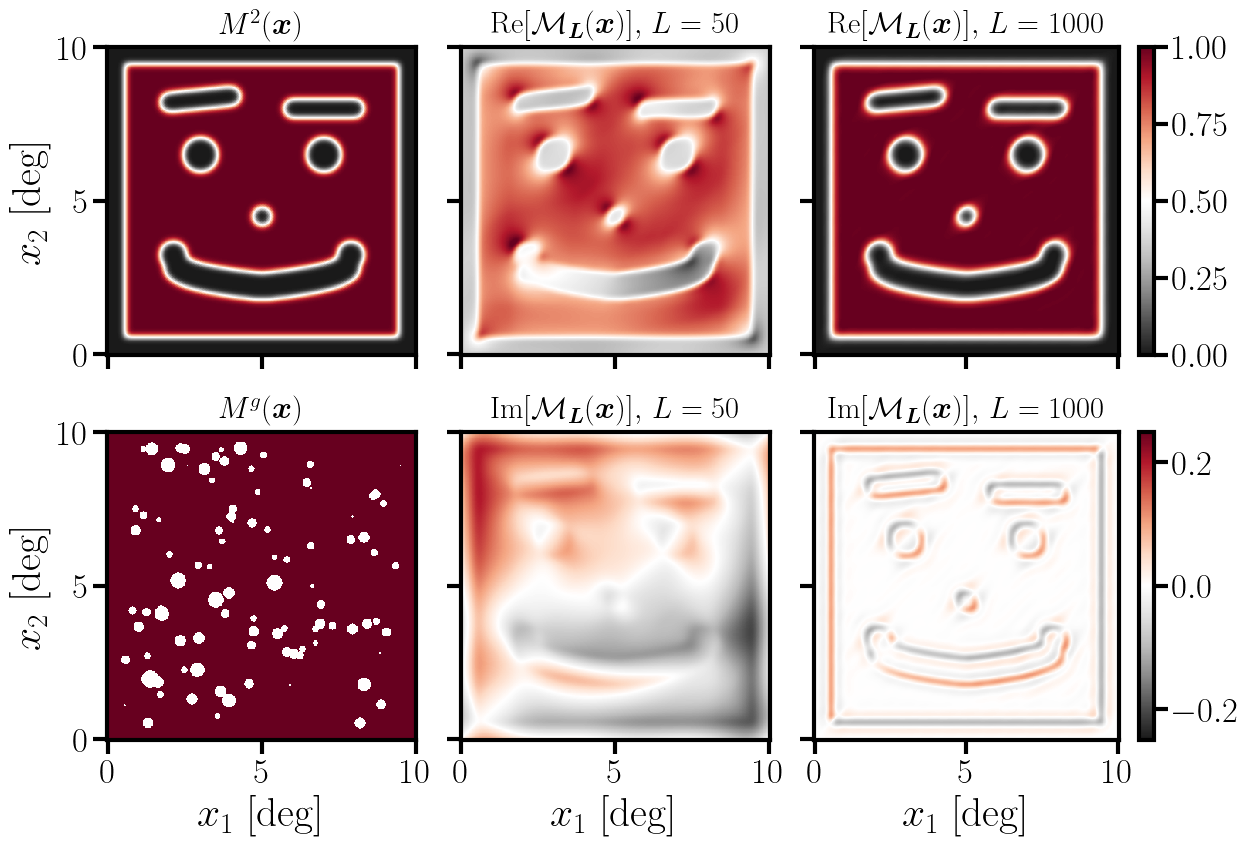

In [3]:
fig,ax = plt.subplots(2,3,figsize=(13.5,9),sharey=True,gridspec_kw={'width_ratios':[1,1,1.1],'wspace':0.14,'hspace':0.25})

vminR = 0
vmaxR = 1
vminI = -0.25
vmaxI = 0.25

cmapR = 'RdGy_r'
cmapI = 'RdGy_r'

x = baseMap.dX * (np.arange(baseMap.nX+1) - 0.5)
y = baseMap.dY * (np.arange(baseMap.nY+1) - 0.5)
x,y = np.meshgrid(x, y, indexing='ij')

ax[0,0].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip((msk_pri**2).T,axis=1), linewidth=0, rasterized=True,vmin=vminR,vmax=vmaxR,cmap=cmapR)
ax[0,1].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip(mskEffreal50.T,axis=1), linewidth=0, rasterized=True,vmin=vminR,vmax=vmaxR,cmap=cmapR)
ax[0,2].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip(mskEffreal1000.T,axis=1), linewidth=0, rasterized=True,vmin=vminR,vmax=vmaxR,cmap=cmapR)

ax[1,0].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip(msk_gal.T,axis=1), linewidth=0, rasterized=True,vmin=vminI,vmax=vmaxI,cmap=cmapI)
ax[1,1].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip(mskEffimag50.T,axis=1), linewidth=0, rasterized=True,vmin=vminI,vmax=vmaxI,cmap=cmapI)
ax[1,2].pcolormesh(x*180./np.pi, y*180./np.pi, np.flip(mskEffimag1000.T,axis=1), linewidth=0, rasterized=True,vmin=vminI,vmax=vmaxI,cmap=cmapI)

for i in range(3): 
    ax[0,i].set_xticks([0,5,10]) ; ax[1,i].set_xticks([0,5,10])
    ax[0,i].set_yticks([0,5,10]) ; ax[1,i].set_yticks([0,5,10])
    ax[1,i].set_xlabel(r'$x_1$ [deg]') ; ax[0,i].set_xticklabels([])
ax[0,0].set_ylabel(r'$x_2$ [deg]')
ax[1,0].set_ylabel(r'$x_2$ [deg]')

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax[0,2])
cax = divider.append_axes("right", size="5%", pad=0.2)
plt.colorbar(plt.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=vminR,vmax=vmaxR), cmap=cmapR),cax=cax)
#
divider = make_axes_locatable(ax[1,2])
cax = divider.append_axes("right", size="5%", pad=0.2)
plt.colorbar(plt.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=vminI,vmax=vmaxI), cmap=cmapI),cax=cax)

ax[0,0].text(5,10.7,r'$M^2(\boldsymbol{x})$',ha='center', va='center')
ax[0,1].text(5,10.7,r'$\text{Re}[\mathcal{M}_{\boldsymbol{L}}(\boldsymbol{x})],\,L=50$',ha='center', va='center')
ax[0,2].text(5,10.7,r'$\text{Re}[\mathcal{M}_{\boldsymbol{L}}(\boldsymbol{x})],\,L=1000$',ha='center', va='center')

ax[1,0].text(5,10.7,r'$M^g(\boldsymbol{x})$',ha='center', va='center')
ax[1,1].text(5,10.7,r'$\text{Im}[\mathcal{M}_{\boldsymbol{L}}(\boldsymbol{x})],\,L=50$',ha='center', va='center')
ax[1,2].text(5,10.7,r'$\text{Im}[\mathcal{M}_{\boldsymbol{L}}(\boldsymbol{x})],\,L=1000$',ha='center', va='center')

plt.savefig('figures/effective_mask.pdf',bbox_inches='tight')

# Verification via Monte Carlo (a.k.a. we tried it on mocks and it works)

In [108]:
# monte carlo
from glob import glob
flist = np.array(sorted(glob('mocks/power_spec*')))
dat = np.array([np.genfromtxt(f) for f in flist])
print('Using',len(flist),'MC sims')

lCen = dat[0][:,0]
# truXtru
mtruXtru = np.mean(dat,axis=0)[:,1]
struXtru = np.std(dat,axis=0)[:,1] / len(flist)**0.5
# galXtru
mgalXtru = np.mean(dat,axis=0)[:,2]
sgalXtru = np.std(dat,axis=0)[:,2] / len(flist)**0.5
# galXrec
mgalXrec = np.mean(dat,axis=0)[:,3]
sgalXrec = np.std(dat,axis=0)[:,3] / len(flist)**0.5

Using 170818 MC sims


In [109]:
# theory predictions
truXtru_thy = Ckg_convolved(one,one)
galXtru_thy = Ckg_convolved(one,msk_gal)
# Mkappa = M^2 approximation
Msq_approx  = Ckg_convolved(msk_pri**2,msk_gal)

### Step 0: check that GRF has the same (measured) power spectrum as the input power

Text(0.5, 1.0, '$\\langle C^{\\kappa\\kappa}_L\\rangle$')

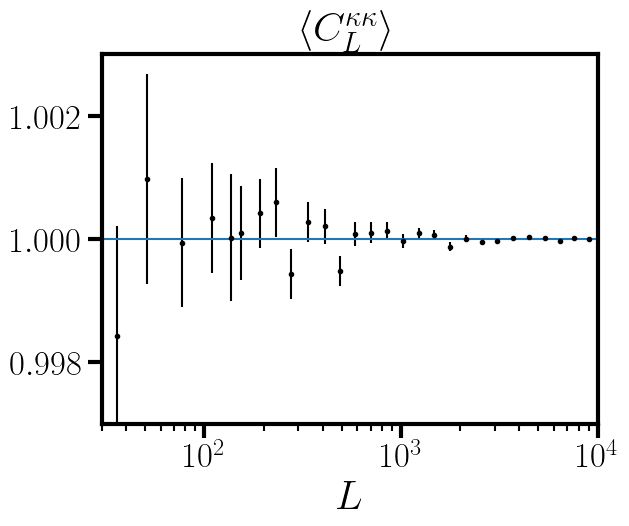

In [110]:
I = np.where((mtruXtru != 0) & (lCen < 10000))

plt.errorbar(lCen[I],mtruXtru[I]/truXtru_thy[I],yerr=struXtru[I]/truXtru_thy[I],ls='',marker='.',c='k')
plt.axhline(y=1,c='C0')

plt.xscale('log') ; plt.xlabel(r'$L$')
plt.xlim(30,10000)
plt.ylim(0.997,1.003)
plt.title(r'$\langle C^{\kappa\kappa}_L\rangle$',pad=10)

Text(0.5, 1.0, '$\\langle C^{\\kappa\\kappa}_L\\rangle$')

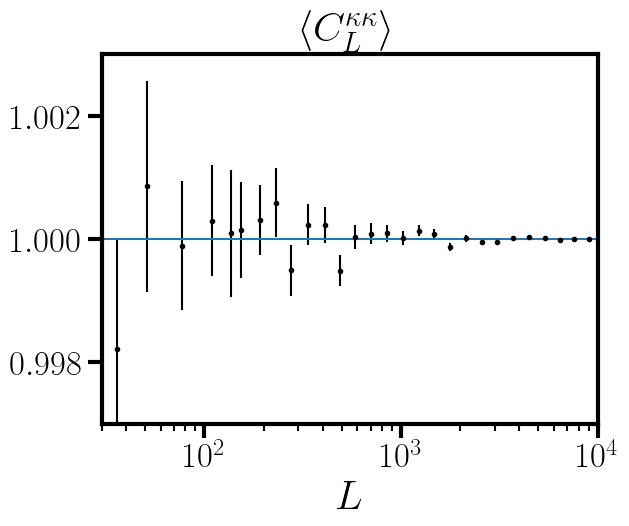

In [115]:
I = np.where((mtruXtru != 0) & (lCen < 10000))

plt.errorbar(lCen[I],mgalXtru[I]/galXtru_thy[I],yerr=sgalXtru[I]/galXtru_thy[I],ls='',marker='.',c='k')
plt.axhline(y=1,c='C0')

plt.xscale('log') ; plt.xlabel(r'$L$')
plt.xlim(30,10000)
plt.ylim(0.997,1.003)
plt.title(r'$\langle C^{\kappa\kappa}_L\rangle$',pad=10)

# Showing that the effective mask works

In [111]:
# 30,50,80,100,200,500,1000,2000
mskEffIso30   = np.genfromtxt('masks/mskEffIso30.txt')
mskEffIso100   = np.genfromtxt('masks/mskEffIso100.txt')
mskEffIso200  = np.genfromtxt('masks/mskEffIso200.txt')
mskEffIso250  = np.genfromtxt('masks/mskEffIso250.txt')
mskEffIso300  = np.genfromtxt('masks/mskEffIso300.txt')
mskEffIso350  = np.genfromtxt('masks/mskEffIso350.txt')
mskEffIso400  = np.genfromtxt('masks/mskEffIso400.txt')
mskEffIso1000  = np.genfromtxt('masks/mskEffIso1000.txt')

In [112]:
M30   = Ckg_convolved(mskEffIso30,msk_gal)
M100   = Ckg_convolved(mskEffIso100,msk_gal)
M200  = Ckg_convolved(mskEffIso200,msk_gal)
#M250  = Ckg_convolved(mskEffIso250,msk_gal)
M300  = Ckg_convolved(mskEffIso300,msk_gal)
#M350  = Ckg_convolved(mskEffIso350,msk_gal)
#M400  = Ckg_convolved(mskEffIso400,msk_gal)

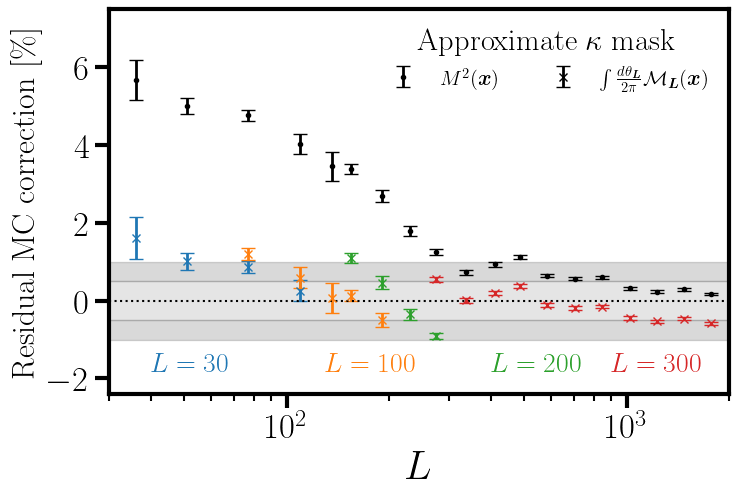

In [114]:
plt.figure(figsize=(8,5))

I = np.where((mgalXtru != 0) & (lCen < 2000))

plt.errorbar(lCen[I],(Msq_approx[I]/mgalXrec[I]-1)*100,yerr=sgalXrec[I]*100/Msq_approx[I],ls='',marker='.',c='k',lw=2,capsize=5,label=r'$M^2(\boldsymbol{x})$')
plt.errorbar([1],[20],yerr=[1],ls='',marker='x',c='k',lw=2,capsize=5,label=r'$\int\frac{d\theta_{\boldsymbol{L}}}{2\pi}\mathcal{M}_{\boldsymbol{L}}(\boldsymbol{x})$')

# 30
I = np.where((mgalXtru != 0) & (lCen < 120))
plt.errorbar(lCen[I],(M30[I]/mgalXrec[I]-1)*100,yerr=sgalXrec[I]*100/M30[I],ls='',marker='x',capsize=5,lw=2,c='C0')

# 100
I = np.where((mgalXtru != 0) & (lCen < 200) & (lCen > 60))
plt.errorbar(lCen[I],(M100[I]/mgalXrec[I]-1)*100,yerr=sgalXrec[I]*100/M100[I],ls='',marker='x',capsize=5,lw=2,c='C1')

# 200
I = np.where((mgalXtru != 0) & (lCen < 300) & (lCen > 150))
plt.errorbar(lCen[I],(M200[I]/mgalXrec[I]-1)*100,yerr=sgalXrec[I]*100/M200[I],ls='',marker='x',capsize=5,lw=2,c='C2')

# 300
I = np.where((mgalXtru != 0) & (lCen < 2000) & (lCen > 250))
plt.errorbar(lCen[I],(M300[I]/mgalXrec[I]-1)*100,yerr=sgalXrec[I]*100/M300[I],ls='',marker='x',capsize=5,lw=2,c='C3')


plt.axhline(y=0,c='k',ls='dotted')
legend = plt.legend(loc='upper right',frameon=False,fontsize=15,title=r'Approximate $\kappa$ mask',ncol=2)
plt.xscale('log') ; plt.xlabel(r'$L$')
plt.xlim(30,2000)
plt.ylim(-2.4,7.5)
plt.ylabel(r'Residual MC correction [\%]',fontsize=23)
plt.yticks([-2,0,2,4,6])
plt.fill_between([10,5000],[0.5,0.5],[-0.5,-0.5],color='k',alpha=0.1)
plt.fill_between([10,5000],[-1,-1],[-0.5,-0.5],color='k',alpha=0.15)
plt.fill_between([10,5000],[1,1],[0.5,0.5],color='k',alpha=0.15)
plt.text(40,-1.8,r'$L=30$',c='C0',fontsize=20)
plt.text(130,-1.8,r'$L=100$',c='C1',fontsize=20)
plt.text(400,-1.8,r'$L=200$',c='C2',fontsize=20)
plt.text(900,-1.8,r'$L=300$',c='C3',fontsize=20)

plt.savefig('figures/toy_model_MC_correction.pdf',bbox_inches='tight')

I think that the disagreement between the effective mask and the MC is due to me ignoring that the flat sky is periodic and finite when computing the effective mask

The convolution of the theory works though, verified above (for true kappa crossed with galaxies), so just the effective mask calculation is wrong

In [9]:
#additional checks

In [71]:
I = np.where((mgalXtru != 0) & (lCen < 2000))
mskEffIso30   = np.genfromtxt('masks/mskEffIso30.txt')
M30   = Ckg_convolved(mskEffIso30,msk_gal)
np.real(M30[I][0]),mgalXrec[I][0]

(1.273171755912953e-07, 1.249642255678559e-07)

In [98]:
N = 10
mmm = [np.loadtxt(f'masks/mskEff10_{i}.txt',dtype=np.complex_) for i in range(N)]
what   = [convolve_thy(mmm[i],msk_gal) for i in range(N)]

In [99]:
I = np.where(baseMap.l.flatten() == 36)
for i in range(9): print(what[i].flatten()[I])

[1.25752257e-07-3.57199621e-11j 1.25806606e-07+2.61328181e-10j
 1.25806606e-07-2.61328181e-10j]
[1.26571806e-07-5.24285566e-11j 1.26614353e-07+2.21517055e-10j
 1.26614353e-07-2.21517055e-10j]
[1.26980840e-07-8.74289000e-11j 1.26995382e-07+1.58515343e-10j
 1.26995382e-07-1.58515343e-10j]
[1.27097242e-07-1.31748648e-10j 1.27075673e-07+8.64741023e-11j
 1.27075673e-07-8.64741023e-11j]
[1.26904688e-07-1.68723728e-10j 1.26852797e-07+3.69251942e-11j
 1.26852797e-07-3.69251942e-11j]
[1.26230814e-07-1.86145016e-10j 1.26162901e-07+2.50728693e-11j
 1.26162901e-07-2.50728693e-11j]
[1.26865128e-07-1.58556013e-10j 1.26810814e-07+5.20533039e-11j
 1.26810814e-07-5.20533039e-11j]
[1.27033936e-07-1.17448044e-10j 1.27009584e-07+1.08818880e-10j
 1.27009584e-07-1.08818880e-10j]
[1.26905510e-07-7.28301605e-11j 1.26916893e-07+1.80803129e-10j
 1.26916893e-07-1.80803129e-10j]
